In [ ]:
%cd .. 

/Users/robin/Library/CloudStorage/OneDrive-UniversityofBergen/Documents/Travail/Cours/2026 - ML BCCR Course/code/BCCR-ml-project-example


In [2]:
from src.utils.trained_models import get_trained_model
from src.utils.config import load_config
import pandas as pd

run_id = 'ceca79fb'
config_path = f'outputs/bccr-ml-course/{run_id}/config.yaml'
config = load_config(config_path)
checkpoint_path = f'outputs/bccr-ml-course/{run_id}/checkpoints/best.ckpt'

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/bccr-ml-project/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be

In [3]:
lightning_model, trainer, datamodule = get_trained_model(config, checkpoint_path)

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
GPU available: True (mps), used: Tru

In [4]:
predictions = pd.read_csv('outputs/bccr-ml-course/ceca79fb/predictions.csv', index_col=0, parse_dates=True)

In [6]:
import numpy as np
predictions['error'] = np.abs(predictions['prediction'] - predictions['target'])/predictions['target']
predictions.query("prediction>15")

,prediction,target,data_slice,error
time,,,,
1979-01-06,19.772960,15.151966,train,0.304977
1979-01-07,35.442710,30.892406,train,0.147295
1979-01-08,20.609152,18.418295,train,0.118950
1979-02-26,20.673817,15.824960,train,0.306406
1979-03-02,23.824202,21.407635,train,0.112883
...,...,...,...,...
2024-12-21,15.475706,19.882730,test,0.221651
2024-12-25,20.221725,16.996193,test,0.189780
2024-12-28,15.116762,20.663320,test,0.268425


In [ ]:
datamodule.setup('predict') 


Fitting transforms on the training data...


{'x': tensor([[[-1.0223, -1.0989, -1.3419,  ...,  0.6947,  0.7571,  0.6172],
          [-0.8892, -1.1343, -1.3223,  ...,  1.4680,  1.7112,  1.3677],
          [-0.4885, -0.8252, -1.0693,  ...,  1.9864,  2.1522,  1.8658],
          ...,
          [ 1.5393,  1.6324,  1.4642,  ...,  0.8915,  0.8939,  1.1297],
          [ 1.4664,  1.6060,  1.5568,  ...,  0.8099,  1.1116,  1.4382],
          [ 1.3497,  1.4863,  1.6655,  ...,  0.6181,  1.0954,  1.5777]]]),
 'y': tensor([28.5759]),
 'time': '2024-12-29'}

In [8]:
data_sample = datamodule.dataset_predict.sel('2024-12-29')

In [ ]:
from captum.attr import IntegratedGradients

In [14]:
X_sample = data_sample['x']
X_sample = X_sample.requires_grad_().to('mps')

In [15]:
ig = IntegratedGradients(lightning_model.model)
attributions = ig.attribute(X_sample, target=0)

In [18]:
attributions_numpy = attributions.cpu().detach().numpy().squeeze()

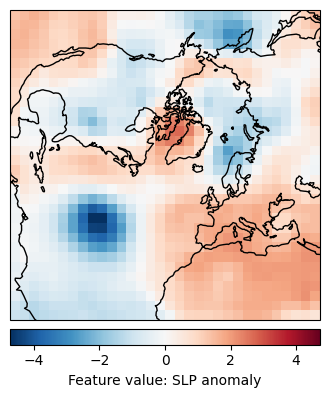

In [51]:
import matplotlib.pyplot as plt
import xarray as xr 
import cartopy.crs as ccrs
fig, ax = plt.subplots(figsize=(4, 6), subplot_kw={'projection': ccrs.NorthPolarStereo()})

X_sample_numpy = X_sample.cpu().detach().numpy().squeeze()
dims = ['x','y']
coords = dict(x=datamodule.dataset_predict.ds.coords['x'], y=datamodule.dataset_predict.ds.coords['y'])
ds_field = xr.DataArray(X_sample_numpy, 
             dims=dims,
             coords=coords)
ds_field = ds_field.assign_coords(lon=datamodule.dataset_predict.ds.coords['x'], lat=datamodule.dataset_predict.ds.coords['y'])

ds_field.plot(ax=ax, transform=ccrs.NorthPolarStereo(), cmap='RdBu_r', 
              cbar_kwargs={'orientation': 'horizontal', 'pad':0.02, 'label': 'Feature value: SLP anomaly'})
ax.coastlines()
# ax.imshow(, cmap='RdBu_r')

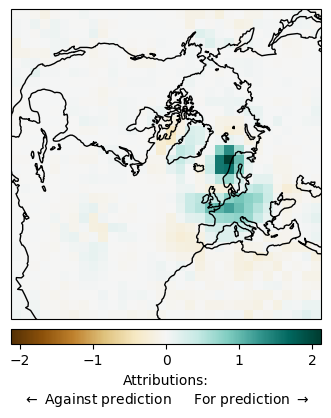

In [57]:
fig, ax = plt.subplots(figsize=(4, 6), subplot_kw={'projection': ccrs.NorthPolarStereo()})

attributions_numpy = attributions.cpu().detach().numpy().squeeze()
dims = ['x','y']
coords = dict(x=datamodule.dataset_predict.ds.coords['x'], y=datamodule.dataset_predict.ds.coords['y'])
ds_field = xr.DataArray(attributions_numpy, 
             dims=dims,
             coords=coords)
ds_field = ds_field.assign_coords(lon=datamodule.dataset_predict.ds.coords['x'], lat=datamodule.dataset_predict.ds.coords['y'])

ds_field.plot(ax=ax, transform=ccrs.NorthPolarStereo(), cmap='BrBG', 
              cbar_kwargs={'orientation': 'horizontal', 'pad':0.02, 'label': 'Attributions:\n'+r'$\leftarrow$ Against prediction $\quad$ For prediction $\rightarrow$'})
ax.coastlines()